# Question Type Classifier Training

Train a LightGBM classifier to predict question type (general, personal, combined) using TF-IDF features from questions.


In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


## Load Data


In [2]:
# Load training data
train_path = Path("queries/questions_ground_truth_train.csv")
df = pd.read_csv(train_path)

print(f"Loaded {len(df)} training examples")
print(f"\nColumns: {list(df.columns)}")

df.head()


Loaded 499 training examples

Columns: ['query_id', 'question', 'question_type', 'generation_strategy', 'source_material', 'ground_truth_chunks', 'expected_sources', 'requires_personal_data']


,query_id,question,question_type,generation_strategy,source_material,ground_truth_chunks,expected_sources,requires_personal_data
0,0bb8e27c-5dd4-4f34-8997-ef66af41a862,Are there any pending action items I haven't c...,personal,sql_schema,NaN,NaN,personal_data,True
1,65a40782-7f75-4edc-8076-7e9eb70f240f,"Based on my recent brood inspections, can you ...",combined,combined_nshot,ENTO-331.pdf,ENTO-331.pdf#chunk_3,personal_data;documents,True
2,f53009d9-3ff2-4879-860c-69724d25ffab,How much damage do small hive beetles actually...,general,pdf_chunk,ENTO-338.pdf,ENTO-338.pdf#chunk_1,documents,False
3,d0567e7b-eaae-4eaa-8b32-902c8864dac9,"Looking at my recent brood inspections, how ca...",combined,combined_nshot,ENTO-331.pdf,ENTO-331.pdf#chunk_3,personal_data;documents,True
4,9fcd2642-5d14-49d4-bf7a-f97e725fad6f,Which of my hives had the lowest activity leve...,personal,sql_schema,NaN,NaN,personal_data,True


In [3]:
# Check class distribution
print("Question type distribution:")
print(df['question_type'].value_counts())
print(f"\nProportions:")
print(df['question_type'].value_counts(normalize=True))


Question type distribution:
question_type
combined    167
personal    166
general     166
Name: count, dtype: int64

Proportions:
question_type
combined    0.334669
personal    0.332665
general     0.332665
Name: proportion, dtype: float64


## Prepare Features and Labels


In [4]:
# Extract features (questions) and labels (question_type)
X_text = df['question'].values
y_string = df['question_type'].values

# Encode string labels to integers for LightGBM
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_string)

# Store class names for later mapping
class_names = label_encoder.classes_

print(f"Features shape: {X_text.shape}")
print(f"Labels shape: {y.shape}")
print(f"\nClass mapping:")
for i, class_name in enumerate(class_names):
    print(f"  {i} -> {class_name}")
print(f"\nSample questions:")
for i in range(3):
    print(f"{i+1}. [{y_string[i]} (encoded: {y[i]})] {X_text[i][:80]}...")


Features shape: (499,)
Labels shape: (499,)

Class mapping:
  0 -> combined
  1 -> general
  2 -> personal

Sample questions:
1. [personal (encoded: 2)] Are there any pending action items I haven't completed from my inspections?...
2. [combined (encoded: 0)] Based on my recent brood inspections, can you help me understand the varroa mite...
3. [general (encoded: 1)] How much damage do small hive beetles actually cause to a hive, and should I be ...


## TF-IDF Vectorization


In [5]:
# Create TF-IDF vectorizer
# Adjust parameters as needed
tfidf = TfidfVectorizer(
    max_features=5000,  # Limit vocabulary size
    ngram_range=(1, 2),  # Unigrams and bigrams
    min_df=2,  # Minimum document frequency
    max_df=0.95,  # Maximum document frequency (ignore very common words)
    stop_words='english',  # Remove English stop words
    lowercase=True,
    strip_accents='unicode'
)

# Fit and transform
X_tfidf = tfidf.fit_transform(X_text)

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"\nFeature matrix is sparse: {hasattr(X_tfidf, 'toarray')}")


TF-IDF matrix shape: (499, 1083)
Vocabulary size: 1083

Feature matrix is sparse: True


In [ ]:
pd.DataFrame(X_tfidf.toarray()).head()

,0,1,2,3,4,5,6,7,8,9,...,1073,1074,1075,1076,1077,1078,1079,1080,1081,1082
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.290018,0.290018,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.318426,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [ ]:
# Get feature names from TF-IDF BEFORE converting (order matters for matching indices)
if hasattr(tfidf, 'get_feature_names_out'):
    tfidf_feature_names = tfidf.get_feature_names_out()
else:
    tfidf_feature_names = tfidf.get_feature_names()

# Convert to list of strings for later use
tfidf_feature_names_list = [str(name) for name in tfidf_feature_names]

# Convert to dense array for LightGBM (or keep sparse if memory allows)
# LightGBM can handle sparse matrices, but converting to dense is often faster
X = X_tfidf.toarray()

print(f"Dense feature matrix shape: {X.shape}")
print(f"Memory usage: {X.nbytes / 1024 / 1024:.2f} MB")
print(f"Feature names count: {len(tfidf_feature_names_list)}")
print(f"Sample feature names: {tfidf_feature_names_list[:10]}")


Dense feature matrix shape: (499, 1083)
Memory usage: 4.12 MB
Feature names count: 1083
Sample feature names: ['acaricide', 'acaricide treatment', 'accurate', 'accurate population', 'accurate results', 'acid', 'acid treatments', 'action', 'action items', 'actions']


## Train/Validation Split


In [ ]:
# Split train data into train and validation sets
# Using 80/20 split with stratification to maintain class balance
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y  # Maintain class proportions
)

# Assign feature names based on stored TF-IDF feature names
# Assign TF-IDF feature names as the DataFrame column names for train and validation sets
X_train_df = pd.DataFrame(X_train, columns=tfidf_feature_names_list)
X_val_df = pd.DataFrame(X_val, columns=tfidf_feature_names_list)


print(f"Training set: {X_train.shape[0]} examples")
print(f"Validation set: {X_val.shape[0]} examples")
print(f"\nTraining class distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nValidation class distribution:")
print(pd.Series(y_val).value_counts())


Training set: 374 examples
Validation set: 125 examples

Training class distribution:
2    125
0    125
1    124
Name: count, dtype: int64

Validation class distribution:
1    42
0    42
2    41
Name: count, dtype: int64


## Train LightGBM Classifier


In [9]:
# Use the feature names we already extracted (they match the feature indices)
# Create LightGBM dataset with feature names
train_data = lgb.Dataset(X_train, label=y_train, feature_name=tfidf_feature_names_list)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data, feature_name=tfidf_feature_names_list)

# LightGBM parameters
params = {
    'objective': 'multiclass',
    'num_class': 3,  # general, personal, combined
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': 0,
    'random_state': 42
}

# Train model
num_round = 100
model = lgb.train(
    params,
    train_data,
    num_round,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=10, verbose=True),
        lgb.log_evaluation(period=10)
    ]
)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

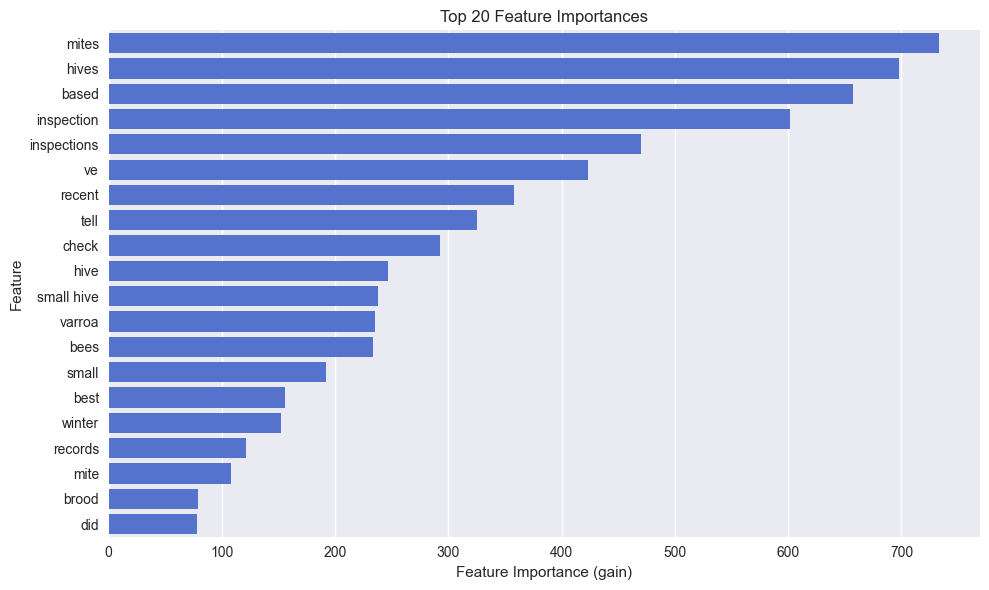

In [ ]:
# plot feature importance for top 20 features

importances = model.feature_importance(importance_type='gain')
feature_names = [f"feature_{i}" for i in range(len(importances))]
top_n = 20
top_indices = np.argsort(importances)[-top_n:][::-1]

# Use the actual TF-IDF feature names for feature importance
importance_df = pd.DataFrame({
    'Feature': tfidf_feature_names_list,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top N feature importances using seaborn, single color, most important at top
import seaborn as sns

top_n = 20
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(top_n),
    x='Importance',
    y='Feature',
    color='royalblue',
    order=importance_df.head(top_n)['Feature']  # ensures descending order from most to least
)
plt.xlabel('Feature Importance (gain)')
plt.title(f'Top {top_n} Feature Importances')
plt.tight_layout()
plt.show()





In [ ]:
# Predictions on validation set
y_pred = model.predict(X_val, num_iteration=model.best_iteration)
y_pred_class = np.argmax(y_pred, axis=1)

# Map back to class names (both predictions and true labels)
y_pred_labels = label_encoder.inverse_transform(y_pred_class)
y_val_labels = label_encoder.inverse_transform(y_val)

# Accuracy
accuracy = accuracy_score(y_val_labels, y_pred_labels)
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val_labels, y_pred_labels, target_names=class_names))


Validation Accuracy: 0.9760

Classification Report:
              precision    recall  f1-score   support

    combined       1.00      0.95      0.98        42
     general       0.98      1.00      0.99        42
    personal       0.95      0.98      0.96        41

    accuracy                           0.98       125
   macro avg       0.98      0.98      0.98       125
weighted avg       0.98      0.98      0.98       125



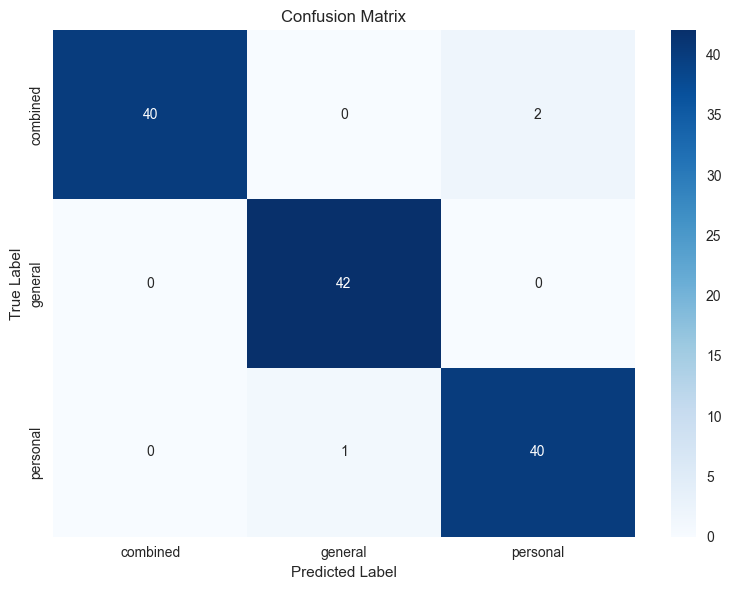

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_val_labels, y_pred_labels, labels=class_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


## Save Model


In [ ]:
# Save model and vectorizer
import pickle
import joblib

model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

# Save LightGBM model
model_path = model_dir / "question_type_classifier_lgbm.txt"
model.save_model(str(model_path))
print(f"Model saved to: {model_path}")

# Save TF-IDF vectorizer
vectorizer_path = model_dir / "tfidf_vectorizer.pkl"
joblib.dump(tfidf, vectorizer_path)
print(f"Vectorizer saved to: {vectorizer_path}")

# Save label encoder (contains class mapping)
encoder_path = model_dir / "label_encoder.pkl"
joblib.dump(label_encoder, encoder_path)
print(f"Label encoder saved to: {encoder_path}")

# Also save class names mapping for convenience
class_mapping = {i: name for i, name in enumerate(class_names)}
mapping_path = model_dir / "class_mapping.pkl"
joblib.dump(class_mapping, mapping_path)
print(f"Class mapping saved to: {mapping_path}")


Model saved to: models/question_type_classifier_lgbm.txt
Vectorizer saved to: models/tfidf_vectorizer.pkl
Label encoder saved to: models/label_encoder.pkl
Class mapping saved to: models/class_mapping.pkl


## Test on Sample Questions


In [ ]:
# Test on some example questions
test_questions = [
    "What were my last inspection notes?",
    "How do I prevent Varroa mites?",
    "Which of my hives had the best pattern and what should I do about it?"
]

# Transform questions
X_test = tfidf.transform(test_questions)
X_test_dense = X_test.toarray()

# Predict
predictions = model.predict(X_test_dense, num_iteration=model.best_iteration)
predicted_classes = np.argmax(predictions, axis=1)
predicted_labels = label_encoder.inverse_transform(predicted_classes)

print("Sample Predictions:")
for q, label, probs in zip(test_questions, predicted_labels, predictions):
    print(f"\nQuestion: {q}")
    print(f"Predicted: {label}")
    print(f"Probabilities:")
    for i, class_name in enumerate(class_names):
        print(f"  {class_name}: {probs[i]:.3f}")


Sample Predictions:

Question: What were my last inspection notes?
Predicted: personal
Probabilities:
  combined: 0.022
  general: 0.006
  personal: 0.972

Question: How do I prevent Varroa mites?
Predicted: general
Probabilities:
  combined: 0.001
  general: 0.998
  personal: 0.002

Question: Which of my hives had the best pattern and what should I do about it?
Predicted: general
Probabilities:
  combined: 0.011
  general: 0.743
  personal: 0.246
